In [1]:
# Minimal imports
from ladder.data import get_data
from ladder.scripts import InterpretableWorkflow # Our workflow object to run the interpretable model
import umap, torch, pyro, os # To set seeds + umaps
import torch.optim as opt # For defining out optimizer;


# For plotting
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# For data loading
import anndata as ad
import scanpy as sc

os.makedirs('plots', exist_ok=True)

## Top 3 CT Marker Recovery

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 292M/292M [00:02<00:00, 105MB/s]


Object saved at ./data/vu_2022_ay_wh.h5ad


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36.0M/36.0M [00:00<00:00, 108MB/s]


Object saved at ./data/mascharak_2022_tn_wh.h5ad


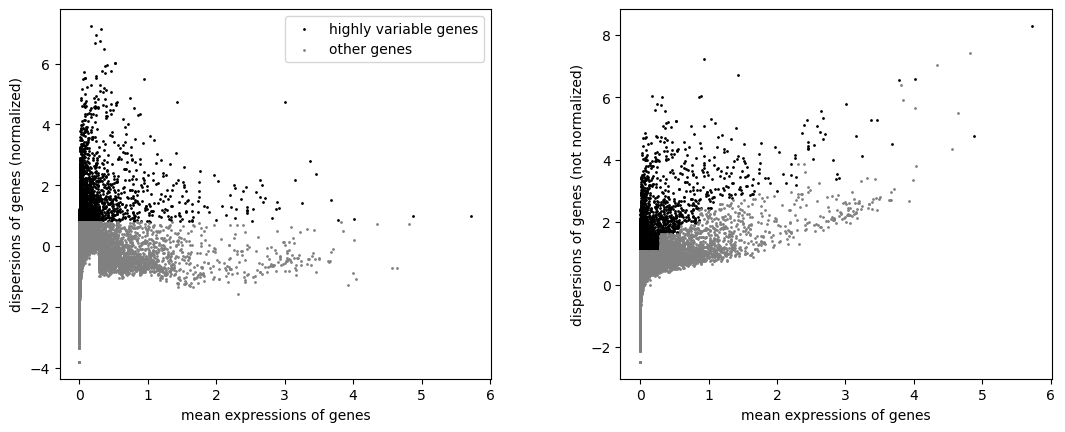

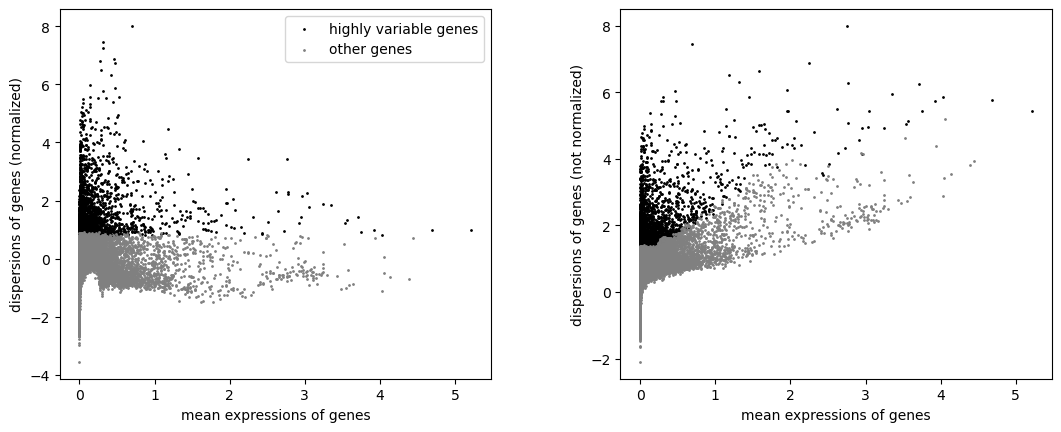

In [2]:
# Download the data object
get_data("Vu")
get_data("Mascharak")

# Load the anndata object
anndata_mascharak = ad.read_h5ad("data/mascharak_2022_tn_wh.h5ad")
anndata_mascharak.layers["normalized"] = anndata_mascharak.X

# Find/subset HVGs & swap to raw counts
sc.pp.highly_variable_genes(anndata_mascharak, n_top_genes=3000)
sc.pl.highly_variable_genes(anndata_mascharak)

anndata_mascharak = anndata_mascharak[:, anndata_mascharak.var["highly_variable"]]
anndata_mascharak.X = anndata_mascharak.layers["counts"]



# Load the anndata object
anndata_vu = ad.read_h5ad("data/vu_2022_ay_wh.h5ad")
anndata_vu.layers["normalized"] = anndata_vu.X

# Find/subset HVGs & swap to raw counts
sc.pp.highly_variable_genes(anndata_vu, n_top_genes=3000, batch_key="sample")
sc.pl.highly_variable_genes(anndata_vu)

anndata_vu = anndata_vu[:, anndata_vu.var["highly_variable"]]
anndata_vu.X = anndata_vu.layers["counts"]

In [3]:
workflow_vu = InterpretableWorkflow(anndata_vu, verbose=True, random_seed=42)
factors_vu = ["time", "age", "broad_type"]
workflow_vu.prep_model(factors_vu, batch_key="sample", model_type='Patches')
workflow_vu.load_model("params/vu_ld")

workflow_mascharak = InterpretableWorkflow(anndata_mascharak, verbose=True, random_seed=42)
factors_mascharak = ["time", "treatment", "broad_type"]
workflow_mascharak.prep_model(factors_mascharak, model_type='Patches')
workflow_mascharak.load_model("params/mascharak_ld")

/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/ladder/data/real_data.py:299: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  anndat.obs[colname] = anndat.obs[colname].astype("category")


Initialized workflow to run interpretable model.

Condition classes : ['time', 'age', 'broad_type']
Number of attributes per class : [3, 2, 10]

Initialized Patches model.
Model arguments: {'reconstruction': 'ZINB_LD', 'batch_correction': True, 'scale_factor': 2.6041666666666666e-06, 'num_labels': 15, 'len_attrs': [3, 2, 10]}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.001, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}


/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/ladder/data/real_data.py:299: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  anndat.obs[colname] = anndat.obs[colname].astype("category")


Initialized workflow to run interpretable model.

Condition classes : ['time', 'treatment', 'broad_type']
Number of attributes per class : [3, 2, 9]

Initialized Patches model.
Model arguments: {'reconstruction': 'ZINB_LD', 'batch_correction': False, 'scale_factor': 2.6041666666666666e-06, 'num_labels': 14, 'len_attrs': [3, 2, 9]}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.001, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}


In [4]:
workflow_vu.get_conditional_loadings()
workflow_mascharak.get_conditional_loadings()

Written condition specific loadings to 'self.anndata.var'.
Written condition specific loadings to 'self.anndata.var'.


## Sep Scores

In [2]:
# Download the data object
get_data("Vu")
get_data("Mascharak")

# Load the anndata object
anndata_mascharak = ad.read_h5ad("data/mascharak_2022_tn_wh.h5ad")
anndata_mascharak.layers["normalized"] = anndata_mascharak.X

# Find/subset HVGs & swap to raw counts
sc.pp.highly_variable_genes(anndata_mascharak, n_top_genes=3000)

anndata_mascharak = anndata_mascharak[:, anndata_mascharak.var["highly_variable"]]
anndata_mascharak.X = anndata_mascharak.layers["counts"]



# Load the anndata object
anndata_vu = ad.read_h5ad("data/vu_2022_ay_wh.h5ad")
anndata_vu.layers["normalized"] = anndata_vu.X

# Find/subset HVGs & swap to raw counts
sc.pp.highly_variable_genes(anndata_vu, n_top_genes=3000, batch_key="sample")

anndata_vu = anndata_vu[:, anndata_vu.var["highly_variable"]]
anndata_vu.X = anndata_vu.layers["counts"]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 292M/292M [00:03<00:00, 91.6MB/s]


Object saved at ./data/vu_2022_ay_wh.h5ad


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36.0M/36.0M [00:00<00:00, 106MB/s]


Object saved at ./data/mascharak_2022_tn_wh.h5ad


## Getting parameters for models example

In [3]:
import anndata as ad
import scanpy as sc
from ladder.scripts import CrossConditionWorkflow


# Initialize workflow object
workflow = CrossConditionWorkflow(anndata_vu, verbose=True, random_seed=42)

# Define the condition classes & batch key to prepare the data
factors = ["time", "age", "broad_type"]
workflow.prep_model(factors, batch_key="sample", cell_type_label_key="broad_type", model_type='SCANVI')

# Load params
workflow.load_model('params/scanvi_vu')

# Get embeddings and run
workflow.write_embeddings()

/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/ladder/data/real_data.py:299: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  anndat.obs[colname] = anndat.obs[colname].astype("category")


Initialized workflow to run cross-condition model.

Condition classes : ['time', 'age', 'broad_type']
Number of attributes per class : [3, 2, 10]

Initialized SCANVI model.
Model arguments: {'reconstruction': 'ZINB', 'batch_correction': True, 'scale_factor': 2.6041666666666666e-06, 'num_labels': 60}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.001, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}
Written embeddings to object 'anndata.obsm' under workflow.


In [4]:
workflow.evaluate_separability('time') 

workflow.evaluate_separability('age') 

workflow.evaluate_separability('broad_type') 

Running for embedding: scanvi_u_latent
Running for embedding: scanvi_z_latent
Results

scanvi_u_latent
kNN Classifier Accuracy : 0.918
K-Means NMI : 0.038
K-Means ARI : 0.001
Average Silhouette Width : 0.467

scanvi_z_latent
kNN Classifier Accuracy : 0.963
K-Means NMI : 0.112
K-Means ARI : 0.096
Average Silhouette Width : 0.535
Running for embedding: scanvi_u_latent
Running for embedding: scanvi_z_latent
Results

scanvi_u_latent
kNN Classifier Accuracy : 0.948
K-Means NMI : 0.005
K-Means ARI : -0.003
Average Silhouette Width : 0.51

scanvi_z_latent
kNN Classifier Accuracy : 0.978
K-Means NMI : 0.04
K-Means ARI : -0.025
Average Silhouette Width : 0.523
Running for embedding: scanvi_u_latent
Running for embedding: scanvi_z_latent
Results

scanvi_u_latent
kNN Classifier Accuracy : 0.937
K-Means NMI : 0.256
K-Means ARI : 0.109
Average Silhouette Width : 0.42

scanvi_z_latent
kNN Classifier Accuracy : 0.999
K-Means NMI : 0.754
K-Means ARI : 0.545
Average Silhouette Width : 0.685


{'scanvi_u_latent': {'kNN Classifier Accuracy': 0.937,
  'K-Means NMI': 0.256,
  'K-Means ARI': 0.109,
  'Average Silhouette Width': 0.42},
 'scanvi_z_latent': {'kNN Classifier Accuracy': 0.999,
  'K-Means NMI': 0.754,
  'K-Means ARI': 0.545,
  'Average Silhouette Width': 0.685}}

In [5]:
score_table = {
    'Vu - Time' : 
    {
    'scVI' : [0.734, 0.032, 0.032, 0.513],
    'scANVI' : [0.963, 0.112, 0.096, 0.535],
    'Patches - Z' : [0.671, 0.005, -0.001, 0.493],
    'Patches - W' : [1.0, 0.403, 0.313, 0.658],
    },

    'Vu - Age' : 
    {
    'scVI' : [0.789, 0.0, 0.001, 0.506],
    'scANVI' : [0.978, 0.04, -0.025, 0.523],
    'Patches - Z' : [0.74, 0.003, -0.007, 0.499],
    'Patches - W' : [1.0, 1.0, 1.0, 0.638],
    },

    'Vu - Cell Type' :
    {
    'scVI' : [0.995, 0.79, 0.628, 0.605],
    'scANVI' : [0.999, 0.754, 0.545, 0.685],
    'Patches - Z' : [0.878, 0.156, 0.054, 0.458],
    'Patches - W' : [0.997, 0.341, 0.204, 0.611],
    },

    'Mascharak - Time' : 
    {
    'scVI' : [0.708, 0.046, 0.028, 0.491],
    'scANVI' : [0.912, 0.038, 0.035, 0.505],
    'Patches - Z' : [0.593, 0.002, -0.003, 0.484],
    'Patches - W' : [1.0, 0.676, 0.678, 0.648],
    },

    'Mascharak - Treatment' : 
    {
    'scVI' : [0.653, 0.003, 0.003, 0.503],
    'scANVI' : [0.895, 0.007, 0.003, 0.509],
    'Patches - Z' : [0.613, 0.0, 0.0, 0.5],
    'Patches - W' : [1.0, 0.178, 0.237, 0.645],
    },

    'Mascharak - Cell Type' : 
    {
    'scVI' : [0.986, 0.776, 0.579, 0.591],
    'scANVI' : [0.992, 0.825, 0.671, 0.664],
    'Patches - Z' : [0.649, 0.025, 0.008, 0.455],
    'Patches - W' : [0.974, 0.346, 0.164, 0.563],
    },
}

## Fig

/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/scanpy/plotting/_stacked_violin.py:572: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  row_ax.set_yscale("log")


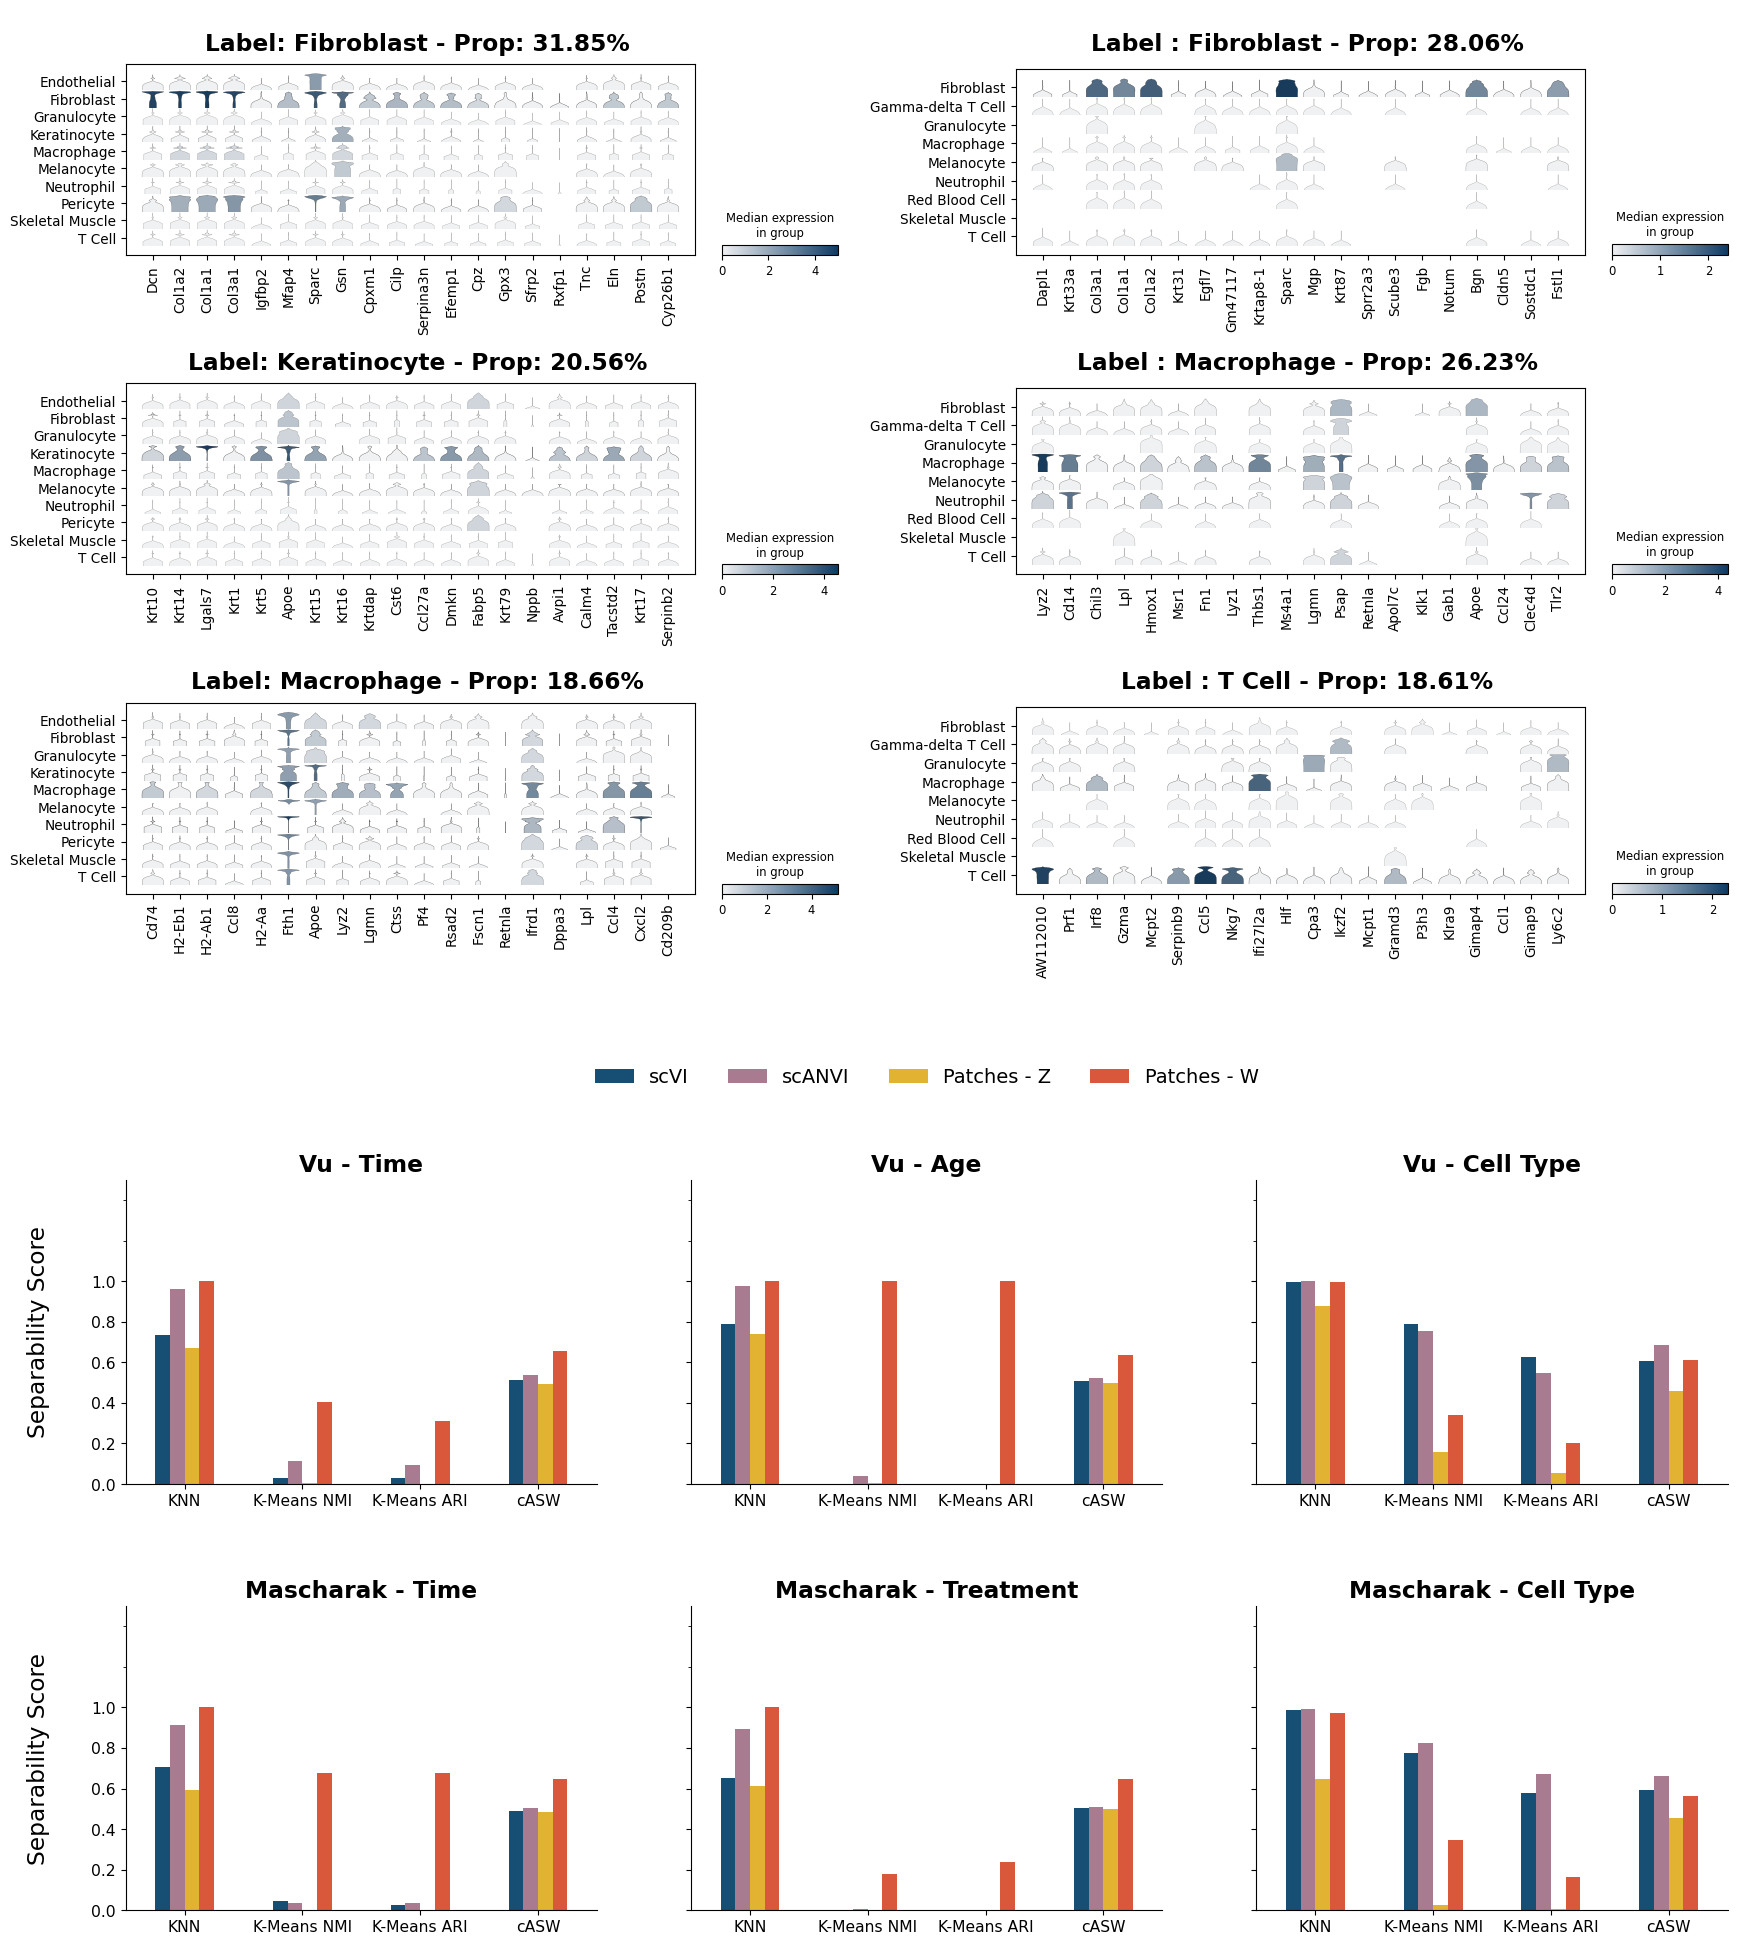

In [24]:
import matplotlib

fontsize=14
figscale = 2.5
leg_bbox = (0.5, 0.3)
sep_palette = matplotlib.colors.ListedColormap(np.array(sns.color_palette(['#164F73', '#A87B90', '#E2B232', '#D9583B',])))
cmap_violin = sns.light_palette('#0D3B66', as_cmap=True)

# Fig grid
fig = plt.figure(figsize=(21 * 1/2.54 * figscale, 25.08 * 1/2.54 * figscale))
gs = gridspec.GridSpec(2, 1, hspace = 0.15, figure=fig, height_ratios=[5,5])
ax = [fig.add_subplot(gs[i//1, i%1]) for i in range(2)]
for axs in ax:
    axs.axis('off')

# Subfig grids
gs_markers = gridspec.GridSpecFromSubplotSpec(3,2,ax[0], hspace=0.3, wspace=0.25)
ax_markers = [fig.add_subplot(gs_markers[i//2, i%2]) for i in range(6)]

gs_sep_main = gridspec.GridSpecFromSubplotSpec(2,1,ax[1], height_ratios=[1,10])
ax_sep_main = [fig.add_subplot(gs_sep_main[i, 0]) for i in range(2)]
for axs in ax_sep_main:
    axs.axis('off')

gs_sep = gridspec.GridSpecFromSubplotSpec(2,3,ax_sep_main[1], hspace=0.4)
ax_sep = [fig.add_subplot(gs_sep[0, 0])]
ax_sep = ax_sep + [fig.add_subplot(gs_sep[i//3, i%3], sharey = ax_sep[0]) for i in range(1,6)]


# CT marker plots - top 3 most repr cts - top 20 markers
## Vu
i=0
for ct in list(workflow_vu.anndata.obs["broad_type"].value_counts().index[:3]):
    obj = sc.pl.stacked_violin(workflow_vu.anndata, (workflow_vu.anndata.var[f"{ct}_score_Patches"]).sort_values(ascending=False).index[:20], groupby="broad_type", log=True, ax=ax_markers[i], show = False, cmap=cmap_violin)
    obj = obj['mainplot_ax']
    obj.set_yticklabels(obj.get_yticklabels(), fontsize=fontsize * 0.7)
    obj.set_xticklabels(obj.get_xticklabels(), fontsize=fontsize * 0.7)
    ax_markers[i].set_title(f"Label: {ct} - Prop: {np.round((workflow_vu.anndata.obs["broad_type"].value_counts()[ct] / len(workflow_vu.anndata)) * 100,2)}%", y=0.8, x=0.41, loc="center", weight="bold", fontsize=fontsize*1.2)
    i += 2

## Mascharak
i=1
for ct in list(workflow_mascharak.anndata.obs["broad_type"].value_counts().index[:3]):
    obj = sc.pl.stacked_violin(workflow_mascharak.anndata, (workflow_mascharak.anndata.var[f"{ct}_score_Patches"]).sort_values(ascending=False).index[:20], groupby="broad_type", log=True, ax=ax_markers[i], show = False, cmap=cmap_violin)
    obj = obj['mainplot_ax']
    obj.set_yticklabels(obj.get_yticklabels(), fontsize=fontsize * 0.7)
    obj.set_xticklabels(obj.get_xticklabels(), fontsize=fontsize * 0.7)
    ax_markers[i].set_title(f"Label : {ct} - Prop: {np.round((workflow_mascharak.anndata.obs["broad_type"].value_counts()[ct] / len(workflow_mascharak.anndata)) * 100,2)}%", y=0.8, x=0.41, loc="center", weight="bold", fontsize=fontsize*1.2)
    i += 2


# Separability plots
## Plots
i = 0
for attr in score_table.keys():
    data = score_table[attr]
    font_factor = 1.9
    ax_sep[i].spines[['right', 'top']].set_visible(False)
    df = pd.DataFrame(data).T
    df.columns = ['KNN', 'K-Means NMI', 'K-Means ARI', 'cASW']
    df = df.T
    models = df.plot(
        kind='bar',
        linewidth=0,
        stacked=False,
        ax=ax_sep[i],
        legend=True,
        grid=False,
        zorder=1,
        cmap=sep_palette,
    )
    
    h,l = models.get_legend_handles_labels()
    ax_sep[i].legend([], [], frameon=False)
    
    lablist = np.repeat(list(data.keys()), 4)
    
    #for k, patch in enumerate(ax_sep[i].patches):
    #    ax_sep[i].annotate(lablist[k], (patch.get_x() + 0.02, patch.get_height() + 0.05), rotation=90)
    
    
    
        
    ax_sep[i].set_ylim(top=1.5, bottom=0)
    ax_sep[i].set_yticks(np.round(np.linspace(0,1,6), 2))
    ax_sep[i].set_yticklabels(np.round(np.linspace(0,1,6), 2), fontsize=fontsize* 0.8)
    ax_sep[i].set_ylabel("Separability Score", labelpad=30, fontsize=fontsize*1.2)
    ax_sep[i].set_xticks(ax_sep[i].get_xticks())
    ax_sep[i].set_xticklabels(ax_sep[i].get_xticklabels(), rotation=0, fontsize=fontsize * 0.8)
    ax_sep[i].set_title(f'{attr}', weight="bold", fontsize=fontsize*1.2)
    i += 1

## Legend
ax_sep_main[0].legend(h, l, title='', title_fontproperties={'weight' : 'bold', 'size' : fontsize*1.2}, frameon=False, ncol=4, bbox_to_anchor=leg_bbox, loc='center', alignment='center', fontsize=fontsize)


plt.savefig('plots/final/fig_4.png', dpi=300, bbox_inches='tight')
plt.show()